# Standardizing medication names from free text

Prescriptions, discharge summaries, and pharmacy records name drugs inconsistently: brand
names, abbreviations, and misspellings like "Paracetomol", "Amoxycillin", and "Asprin".
Before you can compute drug-utilization statistics, check for interactions, or link to a
formulary, each mention has to map to a canonical generic name.

This is the same matching task as the district example with a different vocabulary. It also
asks a question that comes up constantly in biomedical NLP: does a domain-specific model beat
a general one? We compare a general sentence-transformer against a PubMedBERT model and let
the assessor decide. A small generic-drug table ships with the package, so this runs offline.

In [1]:
import pandas as pd
from importlib.resources import files

from alethia import alethia, assess_models

meds = pd.read_csv(files("alethia.data") / "medications_reference.csv")
references = meds["generic_name"].tolist()
print(f"{len(references)} canonical generic drug names")
meds.head()

62 canonical generic drug names


,generic_name,therapeutic_class
0,Amitriptyline,Nervous system
1,Amlodipine,Cardiovascular system
2,Amoxicillin,Alimentary tract and metabolism
3,Aspirin,Nervous system
4,Atenolol,Cardiovascular system


## Messy drug mentions

Misspellings and regional spellings of common medications.

In [2]:
dirty = [
    "Paracetomol", "Ibuprofin", "Amoxycillin", "Atorvastatine",
    "Omeprazol", "Azithromicin", "Cetrizine", "Asprin", "Pantaprazole",
]
len(dirty)

9

In [3]:
result = alethia(dirty, references, model="all-MiniLM-L6-v2")
result[["given_entity", "alethia_prediction", "alethia_score"]]

,given_entity,alethia_prediction,alethia_score
0,Paracetomol,Paracetamol,0.746327
1,Ibuprofin,Ibuprofen,0.613571
2,Amoxycillin,Amoxicillin,0.920773
3,Atorvastatine,Atorvastatin,0.932091
4,Omeprazol,Omeprazole,0.943639
5,Azithromicin,Azithromycin,0.833106
6,Cetrizine,Cetirizine,0.706065
7,Asprin,Aspirin,0.698144
8,Pantaprazole,Pantoprazole,0.732005


## General vs biomedical model

It is tempting to assume a biomedical model always wins on medical text. The assessor lets
you check that on your own data, without labels. We compare a general sentence-transformer
against `pritamdeka/S-PubMedBert-MS-MARCO`, a PubMedBERT model trained for retrieval.

In [4]:
report = assess_models(
    queries=dirty,
    references=references,
    models={
        "MiniLM (general)": "all-MiniLM-L6-v2",
        "PubMedBERT (biomedical)": "pritamdeka/S-PubMedBert-MS-MARCO",
    },
)
report.to_table()[["model", "score", "alignment_loss", "mean_margin", "mutual_nn_rate"]]

,model,score,alignment_loss,mean_margin,mutual_nn_rate
0,MiniLM (general),4.75,0.710414,0.245238,1.0
1,PubMedBERT (biomedical),-4.75,0.168803,0.037989,1.0


In [5]:
print("Recommended model for this data:", report.best.name)

Recommended model for this data: MiniLM (general)


The assessor prefers the general model here. PubMedBERT-MS-MARCO is tuned for matching
questions to passages, not short drug tokens, so its top-match confidence on this vocabulary
is weak. The domain label on a model is not a guarantee; the data decides. The next notebook
confirms this verdict against ground truth.

## Enriching matches with reference metadata

Matches resolve to canonical names, so you can join back to the reference table to recover
structured fields. Here that is the therapeutic class.

In [6]:
enriched = result.merge(
    meds, left_on="alethia_prediction", right_on="generic_name", how="left"
)
enriched[["given_entity", "alethia_prediction", "therapeutic_class", "alethia_score"]]

,given_entity,alethia_prediction,therapeutic_class,alethia_score
0,Paracetomol,Paracetamol,Nervous system,0.746327
1,Ibuprofin,Ibuprofen,Nervous system,0.613571
2,Amoxycillin,Amoxicillin,Alimentary tract and metabolism,0.920773
3,Atorvastatine,Atorvastatin,Cardiovascular system,0.932091
4,Omeprazol,Omeprazole,Alimentary tract and metabolism,0.943639
5,Azithromicin,Azithromycin,Antiinfectives for systemic use,0.833106
6,Cetrizine,Cetirizine,Respiratory system,0.706065
7,Asprin,Aspirin,Nervous system,0.698144
8,Pantaprazole,Pantoprazole,Alimentary tract and metabolism,0.732005


## Visualizing the reference space

The assessor's metrics are geometric, so it helps to see the geometry. We reduce the
reference embeddings to two dimensions with PCA and colour each drug by its therapeutic
class. If the model organizes the vocabulary well, drugs in the same class sit near each
other. `do_umap` is a drop-in alternative for a non-linear view.

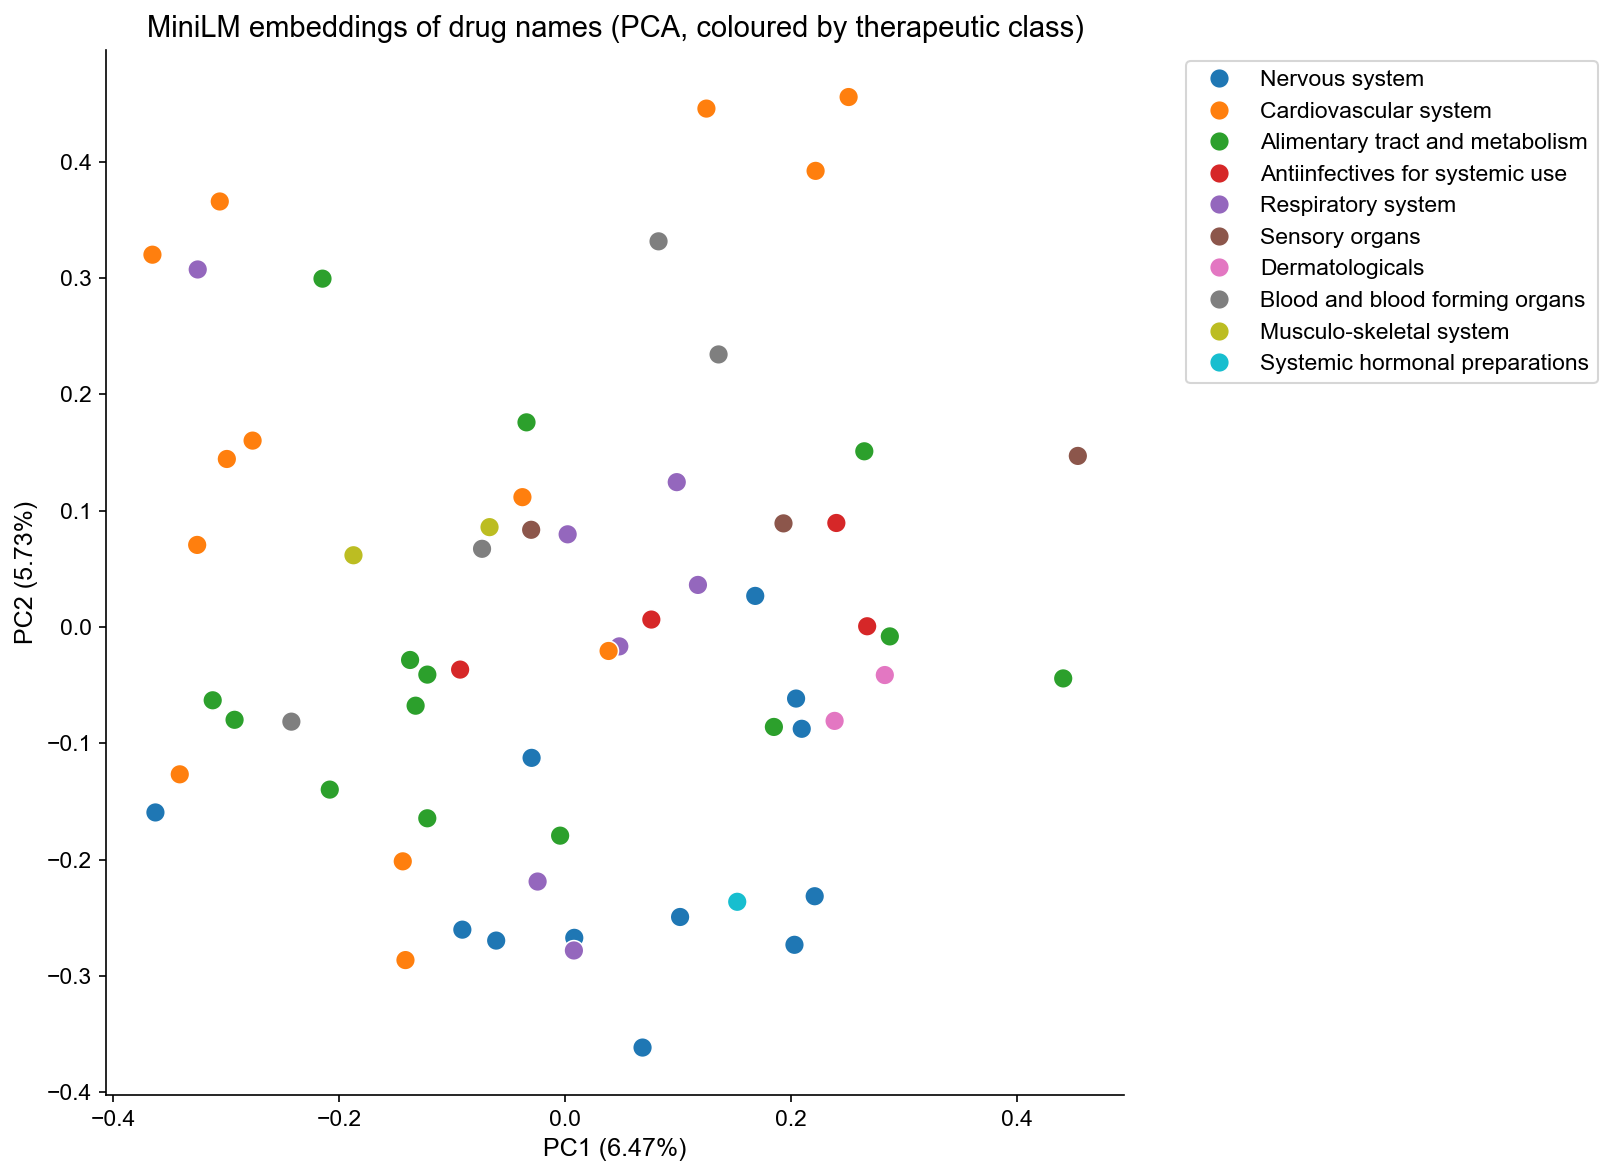

In [7]:
import matplotlib.pyplot as plt
from alethia import as_embedder, do_pca, plot_embedding, setup_matplotlib

setup_matplotlib()  # Arial, crisp DPI, legible default sizes

ref_emb = as_embedder("all-MiniLM-L6-v2").encode(references)
coords, explained = do_pca(ref_emb, n_components=2, return_expl_var=True)

plt.figure(figsize=(11, 8))
plot_embedding(
    coords,
    labels=meds["therapeutic_class"].tolist(),
    explained_var=explained,
    title="MiniLM embeddings of drug names (PCA, coloured by therapeutic class)",
    point_size=90,
)

## Takeaways

- Free-text medication standardization is entity matching against a drug vocabulary.
- A biomedical model is not automatically the right choice; assess it on your data first.
- Resolving to canonical names lets you join back to structured metadata (class, code, dose
  form) for downstream analysis.
- PCA or UMAP projections (do_pca, do_umap, plot_embedding) make the embedding
  geometry the assessor scores directly inspectable.